# Data Audit — LiFUS-BRICK Project

This notebook audits the rsfMRI dataset from the OSF repository (https://osf.io/fhqwd/overview).
For each file, it extracts subject ID, condition (pre/post sonication), file format, data dimensions, TR, and number of timepoints.
Output is used to populate the data audit table in Report 1 and to confirm that every subject has both a pre- and post-sonication scan.

## Import Libraries

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
import glob
import scipy

## Load Files

In [11]:
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "models").exists():
    ROOT_DIR = ROOT_DIR.parent

DATA_DIR = ROOT_DIR / "data" / "raw_data"

mat_files = sorted(DATA_DIR.glob("*.mat"))

print(f"Found {len(mat_files)} files")
for f in mat_files:
    print(f.name)

Found 38 files
sub-fuspd01_ses-2_roi-vim_meants.mat
sub-fuspd01_ses-2_roi-zi_meants.mat
sub-fuspd03_ses-2_roi-vim_meants.mat
sub-fuspd03_ses-2_roi-zi_meants.mat
sub-fuspd04_ses-2_roi-vim_meants.mat
sub-fuspd04_ses-2_roi-zi_meants.mat
sub-fuspd06_ses-2_roi-vim_meants.mat
sub-fuspd06_ses-2_roi-zi_meants.mat
sub-fuspd07_ses-2_roi-vim_meants.mat
sub-fuspd07_ses-2_roi-zi_meants.mat
sub-fuspd08_ses-2_roi-vim_meants.mat
sub-fuspd08_ses-2_roi-zi_meants.mat
sub-fuspd09_ses-2_roi-vim_meants.mat
sub-fuspd09_ses-2_roi-zi_meants.mat
sub-fuspd11_ses-2_roi-vim_meants.mat
sub-fuspd11_ses-2_roi-zi_meants.mat
sub-fuspd12_ses-2_roi-vim_meants.mat
sub-fuspd12_ses-2_roi-zi_meants.mat
sub-fuspd13_ses-2_roi-vim_meants.mat
sub-fuspd13_ses-2_roi-zi_meants.mat
sub-fuspd15_ses-2_roi-vim_meants.mat
sub-fuspd15_ses-2_roi-zi_meants.mat
sub-fuspd16_ses-2_roi-vim_meants.mat
sub-fuspd16_ses-2_roi-zi_meants.mat
sub-fuspd18_ses-2_roi-vim_meants.mat
sub-fuspd18_ses-2_roi-zi_meants.mat
sub-fuspd19_ses-2_roi-vim_meants.mat

38 files, consistent with the n=19 study participants over 2 sessions.

## Data Auditing

Check dict keys

In [14]:
mat = scipy.io.loadmat(mat_files[0])
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'target_meants_pre', 'target_meants_post', 'fn', 'mpre', 'mpost'])


In [15]:
print() #print file name
print('target_meants_pre:', mat['target_meants_pre'].shape)
print('target_meants_post:', mat['target_meants_post'].shape)
print('mpre:', mat['mpre'].shape)
print('mpost:', mat['mpost'].shape)
print('fn:', mat['fn'])


target_meants_pre: (240, 1)
target_meants_post: (240, 1)
mpre: (240, 23)
mpost: (240, 23)
fn: [[array(['lh_Ca'], dtype='<U5')]
 [array(['lh_GPe'], dtype='<U6')]
 [array(['lh_GPi'], dtype='<U6')]
 [array(['lh_Pu'], dtype='<U5')]
 [array(['lh_STH'], dtype='<U6')]
 [array(['lh_cerebellum_dentate'], dtype='<U21')]
 [array(['lh_cerebellum_motor'], dtype='<U19')]
 [array(['lh_paracentral_smooth3mm'], dtype='<U24')]
 [array(['lh_postcentral_smooth3mm'], dtype='<U24')]
 [array(['lh_precentral_smooth3mm'], dtype='<U23')]
 [array(['lh_superiorfrontal_smooth3mm'], dtype='<U28')]
 [array(['lh_zi'], dtype='<U5')]
 [array(['rh_Ca'], dtype='<U5')]
 [array(['rh_GPe'], dtype='<U6')]
 [array(['rh_GPi'], dtype='<U6')]
 [array(['rh_Pu'], dtype='<U5')]
 [array(['rh_STH'], dtype='<U6')]
 [array(['rh_cerebellum_dentate'], dtype='<U21')]
 [array(['rh_cerebellum_motor'], dtype='<U19')]
 [array(['rh_paracentral_smooth3mm'], dtype='<U24')]
 [array(['rh_postcentral_smooth3mm'], dtype='<U24')]
 [array(['rh_precen

Cycle through files and create a df containing requested file info for data audit.

In [38]:
records = []

for f in mat_files:
    file = scipy.io.loadmat(f)
    
    name = f.stem  # filename without .mat

    with open(f, 'rb') as fh:
        header = fh.read(10)

    notes = []
    
    # Add notes for timepoint mismatch
    if file['mpre'].shape[0] != file['mpost'].shape[0]:
        notes.append('pre/post timepoint mismatch')

    records.append({
        'filename': name,
        'subject_id': name.split('_')[0].replace('sub-fuspd', ''),        
        'target': name.split('_')[2].replace('roi-', ''),             # VIM or ZI
        'n_timepoints_pre': file['mpre'].shape[0],
        'n_timepoints_post': file['mpost'].shape[0],
        'n_rois_pre': file['mpre'].shape[1] + file['target_meants_pre'].shape[1],  # total ROIs in pre = mpre + target_meants_pre
        'n_rois_post': file['mpost'].shape[1] + file['target_meants_post'].shape[1], # total ROIs in post = mpost + target_meants_post
        'mpre_shape': file['mpre'].shape,
        'mpost_shape': file['mpost'].shape,
        'tr_s': '2.0',                           # repitition time (TR) in seconds from MRI acquisition parameters (Vuong et al. 2026 supplementary)
        'file_format': 'MATLAB 5.0' if b'MATLAB 5.0' in header else 'MATLAB 7.3',
        'notes': '; '.join(notes) if notes else ''
    })

df = pd.DataFrame(records)
df

,filename,subject_id,target,n_timepoints_pre,n_timepoints_post,n_rois_pre,n_rois_post,mpre_shape,mpost_shape,tr_s,file_format,notes
0,sub-fuspd01_ses-2_roi-vim_meants,01,vim,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
1,sub-fuspd01_ses-2_roi-zi_meants,01,zi,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
2,sub-fuspd03_ses-2_roi-vim_meants,03,vim,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
3,sub-fuspd03_ses-2_roi-zi_meants,03,zi,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
4,sub-fuspd04_ses-2_roi-vim_meants,04,vim,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
5,sub-fuspd04_ses-2_roi-zi_meants,04,zi,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
6,sub-fuspd06_ses-2_roi-vim_meants,06,vim,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
7,sub-fuspd06_ses-2_roi-zi_meants,06,zi,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
8,sub-fuspd07_ses-2_roi-vim_meants,07,vim,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,
9,sub-fuspd07_ses-2_roi-zi_meants,07,zi,240,240,24,24,"(240, 23)","(240, 23)",2.0,MATLAB 5.0,


In [37]:
#Save df to csv

DATA_DIR.mkdir(exist_ok=True)
df.to_csv(DATA_DIR / 'data_audit.csv', index=False)

Note: Each file contains 24 ROIs, with the ROI of interest being stored separately.

## Vizualize Data

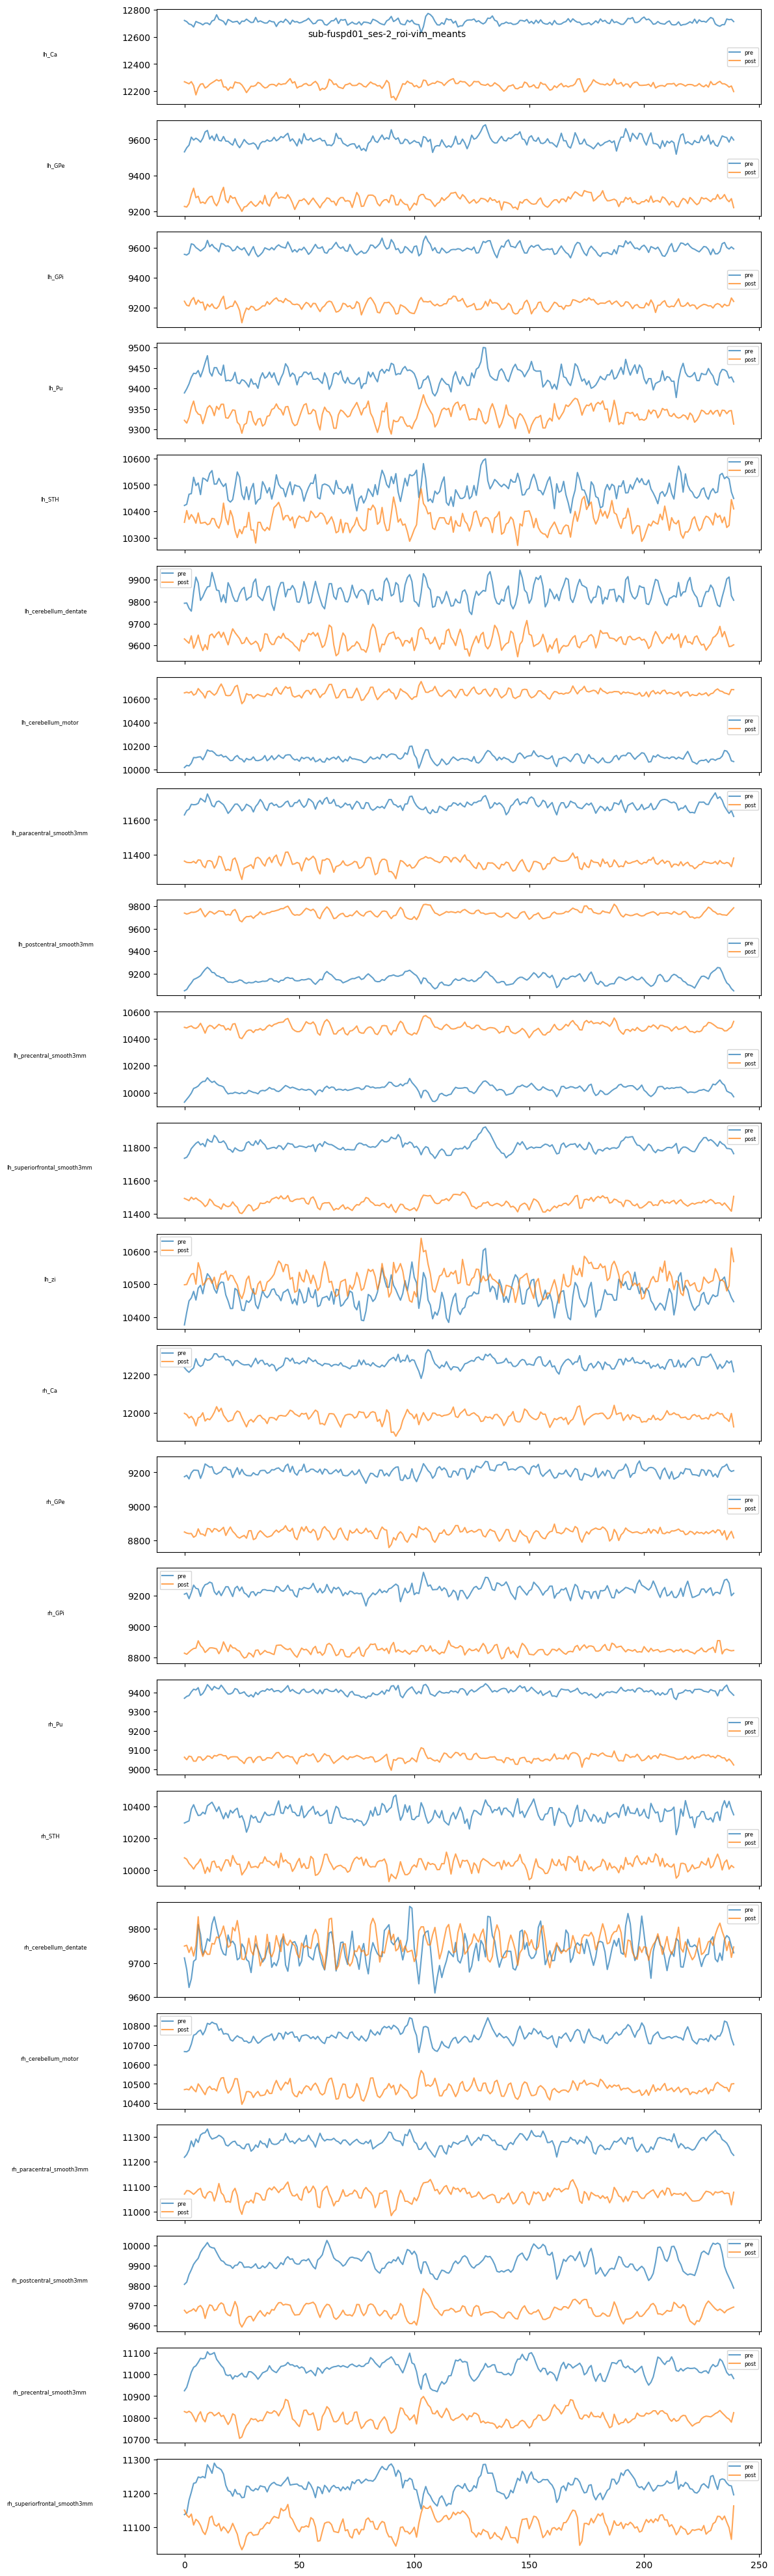

In [34]:
# pick one file to inspect
file = scipy.io.loadmat(mat_files[0])
roi_names = [arr[0] for arr in file['fn'].flatten()]

fig, axes = plt.subplots(23, 1, figsize=(12, 40), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(file['mpre'][:, i], label='pre', alpha=0.7)
    ax.plot(file['mpost'][:, i], label='post', alpha=0.7)
    ax.set_ylabel(roi_names[i], fontsize=6, rotation=0, labelpad=80)
    ax.legend(fontsize=6)

plt.suptitle(mat_files[0].stem, fontsize=10)
plt.tight_layout()
plt.show()

In [45]:
# Go up one level from 'analysis/' to the repository root 'LIFUS-BRICK'
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), os.path.pardir))
PREPROCESSED_DIR = os.path.join(ROOT_DIR, "data", "preprocessed_data")

print(f"Project Root identified as: {ROOT_DIR}")
print(f"Searching for preprocessed data in: {PREPROCESSED_DIR}")

# Gather all preprocessed files
mat_files = [Path(f) for f in glob.glob(os.path.join(PREPROCESSED_DIR, "*.mat"))]

if not mat_files:
    print("❌ No preprocessed files found! Double-check that your preprocessing script ran successfully.")
else:
    target_file_path = mat_files[0]
    print(f"✅ Success! Found {len(mat_files)} files. Target file selected: {target_file_path.name}")

Project Root identified as: c:\Users\USER\Documents\GitHub\LIFUS-BRICK
Searching for preprocessed data in: c:\Users\USER\Documents\GitHub\LIFUS-BRICK\data\preprocessed_data
✅ Success! Found 38 files. Target file selected: sub-fuspd01_ses-2_roi-vim_meants.mat


Plotting all 24 aligned regions for file: sub-fuspd01_ses-2_roi-vim_meants


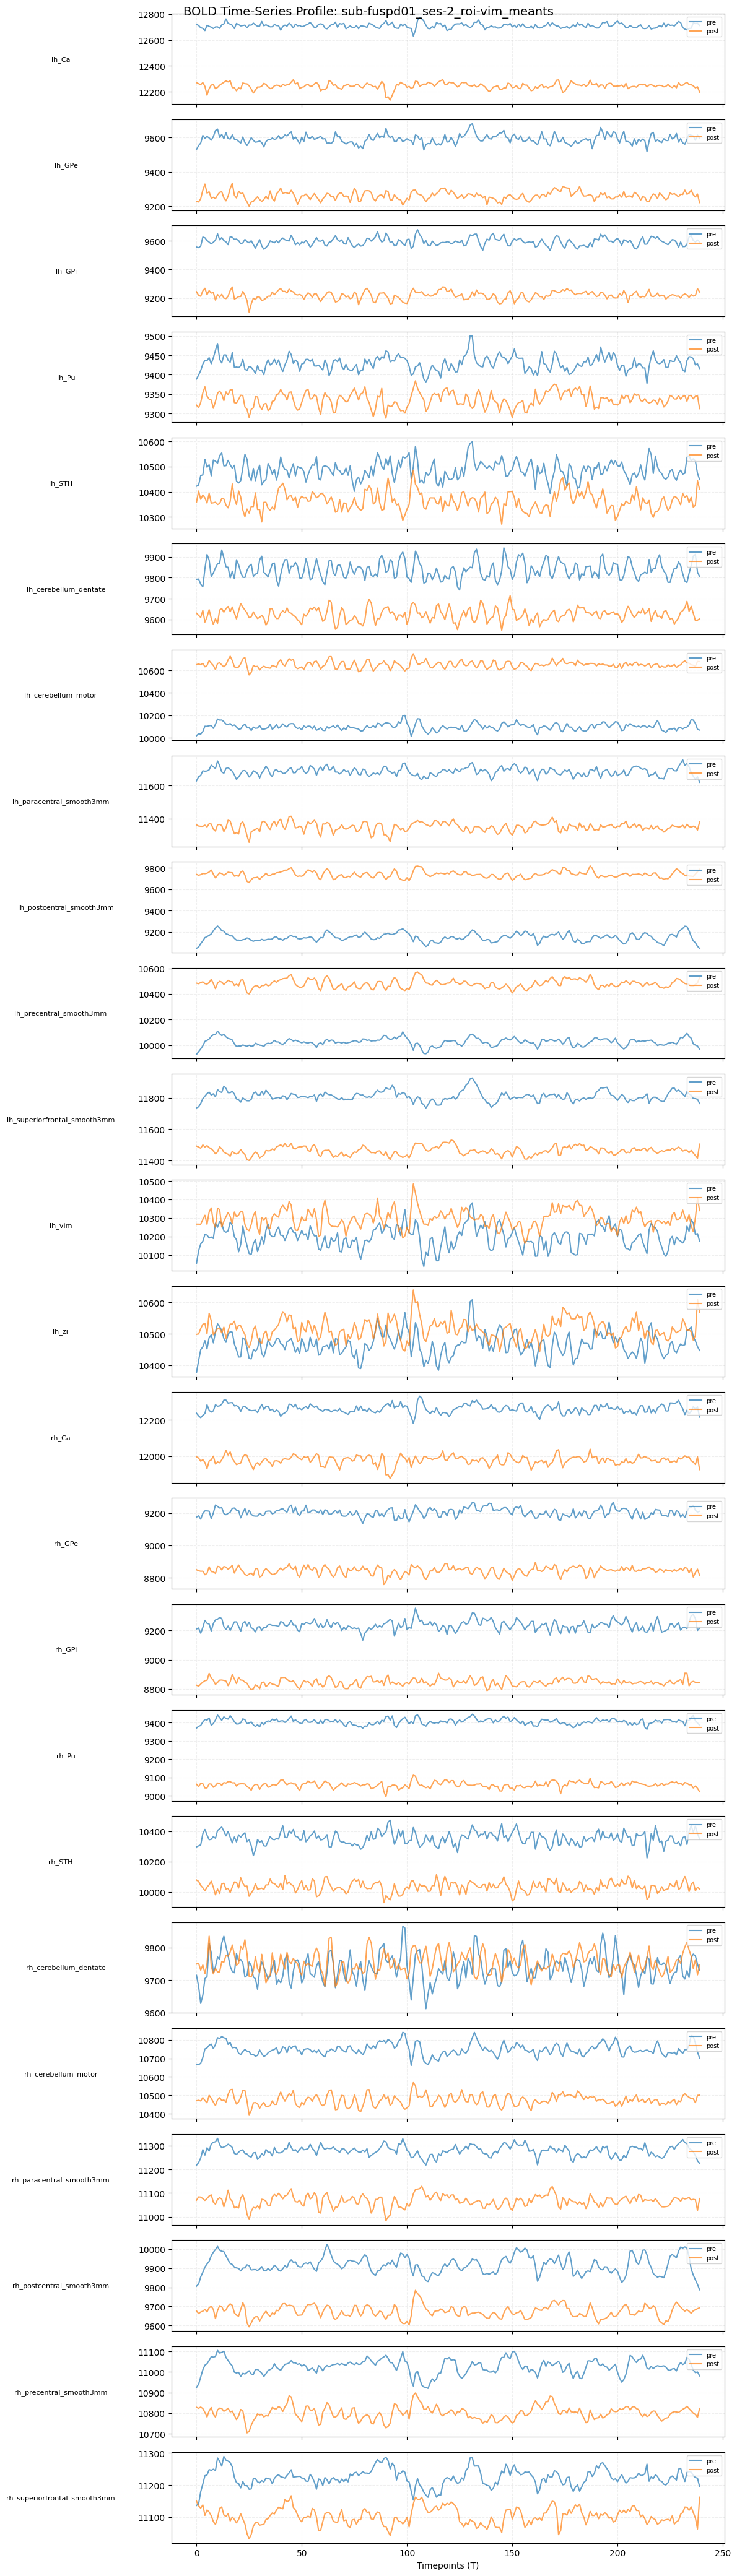

In [46]:
# Double-check that we found a file before plotting
if 'target_file_path' in locals():
    # 1. Load the data fields
    file_data = scipy.io.loadmat(str(target_file_path))
    mpre = file_data['mpre']    # Shape: (240, 24)
    mpost = file_data['mpost']  # Shape: (240, 24)
    
    # 2. Cleanly parse the aligned 24 ROI labels from the 'fn' matrix
    roi_names = []
    for item in file_data['fn'].flatten():
        while isinstance(item, np.ndarray):
            item = item[0] if item.size > 0 else ""
        roi_names.append(str(item).strip())
        
    num_rois = mpre.shape[1]
    print(f"Plotting all {num_rois} aligned regions for file: {target_file_path.stem}")
    
    # 3. Initialize 24 subplots vertically
    fig, axes = plt.subplots(num_rois, 1, figsize=(12, 42), sharex=True)
    
    if num_rois == 1:
        axes = [axes]
        
    # 4. Plot pre- vs post-sonication BOLD data
    for i, ax in enumerate(axes):
        ax.plot(mpre[:, i], label='pre', color='#1f77b4', alpha=0.7)
        ax.plot(mpost[:, i], label='post', color='#ff7f0e', alpha=0.7)
        
        # Style formatting for clear visualization
        ax.set_ylabel(roi_names[i], fontsize=8, rotation=0, labelpad=90, va='center')
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.2, linestyle='--')

    # Add timepoint axis labels at the very bottom
    axes[-1].set_xlabel("Timepoints (T)", fontsize=10)
    
    plt.suptitle(f"BOLD Time-Series Profile: {target_file_path.stem}", fontsize=14, y=0.99)
    plt.tight_layout()
    plt.show()